# Keltner-Channel — breakout or reversion? The channel that promises both.
### EMA(20) ± 2×ATR(10): tested honestly on 21 years of daily data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Breakout_vs_Reversion%3F: Both_noise](https://img.shields.io/badge/Breakout_vs_Reversion%3F-Both_noise-8b949e?style=flat-square)

Here is a recipe you'll find in thousands of trading tutorials: draw a Keltner Channel around price (an exponential moving average with an ATR-based envelope) and trade the pierces. But the tutorials cannot agree *which way* to trade them. Half say 'when price breaks *above* the upper band, the trend is strong — buy.' The other half say 'when price falls *below* the lower band, it has stretched too far — buy the snap-back.' This notebook tests **both claims honestly** — and shows why they cannot both be right.

> 📓 **This is the plain-language layer.** Want the t-stats, bootstrap intervals, and the random-entry control maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from keltner_channel import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "EEM"]
HOLD = 20
CACHE = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(side, cost=0.0, seed=None):
    """Pool fixed-hold trades across the basket."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        if seed is not None:
            sig_n = len(st.channel_entries(b, side=side))
            ent = st.random_entries(b, n=sig_n, seed=seed)
        else:
            ent = st.channel_entries(b, side=side)
        frames.append(st.run_trades(b, ent, hold_days=HOLD, cost_bps=cost))
    return pd.concat(frames, ignore_index=True)

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-14).
R = dict(
    n_bo=1150, bo_mean=81.31, bo_win=61.8, bo_t=4.95,
    rand_bo=116.56, delta_bo=-35.24,
    n_rv=582, rv_mean=147.14, rv_win=61.5, rv_t=4.03,
    rand_rv=140.88, delta_rv=6.26,
    spy_bo_mean=63.97, spy_bo_t=2.07,
    spy_rand_bo=113.05, spy_delta_bo=-49.09,
    spy_rv_mean=246.05, spy_rv_t=3.43,
    spy_rand_rv=157.24, spy_delta_rv=88.81,
    bh_spy=93.85, bh_qqq=131.0, bh_iwm=86.87,
    bh_gld=96.18, bh_eem=78.19,
    bo_net_0=81.31, bo_net_1=80.31, bo_net_2=79.31, bo_net_5=76.31,
    bo_t_0=4.95, bo_t_1=4.89, bo_t_2=4.83, bo_t_5=4.64,
    rv_net_0=147.14, rv_net_1=146.14, rv_net_2=145.14, rv_net_5=142.14,
    rv_t_0=4.03, rv_t_1=4.0, rv_t_2=3.98, rv_t_5=3.89,
    tpy_bo=12, tpy_rv=6,
)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the breakout (close above upper band) signal a real edge? | **No.** Breakout entries earn **81 bps/trade** but a random same-date entry earns **117 bps**. The channel filter makes it **35 bps worse**. |
| Does the reversion (close below lower band) signal a real edge? | **No.** Reversion earns **147 bps/trade** vs random's **141 bps**. Delta: **+6 bps** — statistically indistinguishable from zero. |
| Can both claims be right at once? | **No.** Logically impossible. And both turn out to be noise once market drift is stripped out. |
| Could you trade either? | **No alpha to trade.** The positive gross returns are just the market going up over 21 years. |

> The channel draws pretty lines, but it is not telling you anything useful about what happens next.

## 1 · The claim

The Keltner Channel wraps an exponential moving average (EMA of 20 days) with a volatility envelope: the distance from the mid-line is two times the Average True Range (a measure of daily price swings over the last 10 days). Two claims are made by different trading communities:

> *"When price closes above the upper band, it's in breakout mode — the trend is strong and will continue. Buy."*

> *"When price closes below the lower band, it has stretched too far from fair value. It will snap back. Buy."*

Both camps point to the same lines on the same chart and draw opposite conclusions. At most one can be right. The test below is designed to determine which — if either — is actually adding something beyond just *buying the market on a random day*.

## 2 · So what?

The Keltner Channel is one of the most widely-used volatility channels in retail algorithmic trading. If the breakout claim is true, it's a trend-following machine. If the reversion claim is true, it's a mean-reversion signal. If *both* claims are marketed simultaneously, the channel cannot be both things at once — and testing them together in one rigorous frame exposes the contradiction. The broader lesson: a channel that looks active on a chart is not the same as a channel with predictive power.

## 3 · How would we even know?

The key trick is to use a **random-entry control**. Instead of comparing the channel signal to zero, we compare it to what you'd earn by entering at a *random date* on the same instrument, held for the same 20 days.

Why does this matter? Markets go up most of the time. If you buy SPY after an upper-band pierce and hold for 20 days, you'll often make money — *but so would a random date*. The question is not 'did I make money?' but 'did the channel tell me anything a coin flip didn't already know?'

We test both arms across five instruments (SPY, QQQ, IWM, GLD, EEM) using 21 years of daily data, held for a 20-bar time-exit, matched against a same-size random control.

## 4 · The teardown — let's look at both rules

**First: what does the channel look like on the tape?**

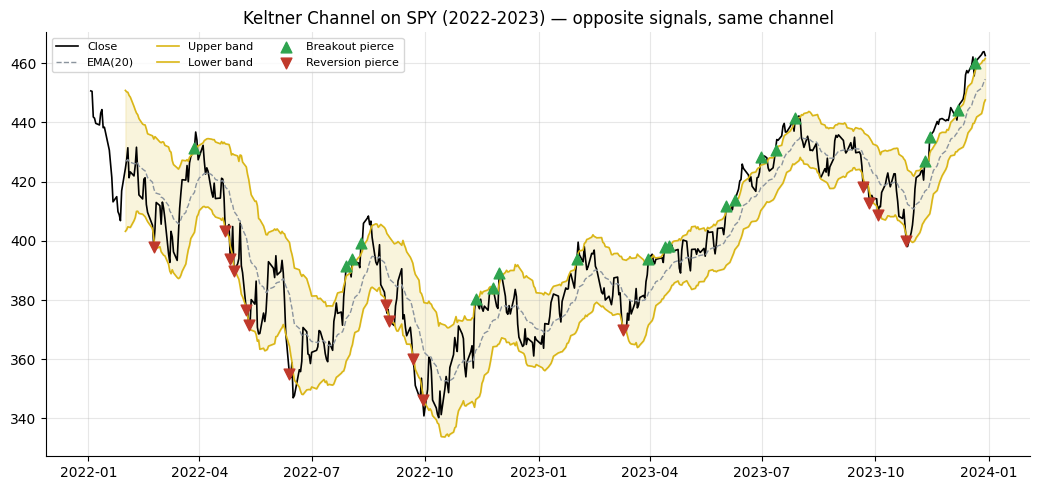

Breakout pierces: 20 | Reversion pierces: 16


In [2]:
# Draw a Keltner Channel on SPY over a representative period.
if HAVE_REAL:
    bars = data.fetch_daily('SPY', fetch=False, cache_dir=CACHE)
    sample = bars['2022-01-01':'2023-12-31']
else:
    sample, _ = data.synthetic_daily(n_days=500, momentum=0.0, seed=128)
kc = st.keltner_channel(sample)
fig, ax = plt.subplots(figsize=(10.5, 5.0))
ax.plot(sample.index, sample['close'], c='k', lw=1.2, label='Close')
ax.plot(kc.index, kc['mid'], c=GREY, lw=1, ls='--', label='EMA(20)')
ax.fill_between(kc.index, kc['lower'], kc['upper'], alpha=0.15, color=AMBER)
ax.plot(kc.index, kc['upper'], c=AMBER, lw=1.2, label='Upper band')
ax.plot(kc.index, kc['lower'], c=AMBER, lw=1.2, label='Lower band')
# Mark pierces
bo_e = st.channel_entries(sample, side='breakout')
rv_e = st.channel_entries(sample, side='reversion')
ax.scatter(bo_e.index, sample.loc[bo_e.index, 'close'], marker='^', c=GREEN, s=60, zorder=5, label='Breakout pierce')
ax.scatter(rv_e.index, sample.loc[rv_e.index, 'close'], marker='v', c=RED, s=60, zorder=5, label='Reversion pierce')
ax.set_title('Keltner Channel on SPY (2022-2023) — opposite signals, same channel')
ax.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.show()
print(f'Breakout pierces: {len(bo_e)} | Reversion pierces: {len(rv_e)}')

The channel clearly marks extremes — the question is whether those extremes predict what comes next. Now the honest comparison: both arms vs a random same-day entry.

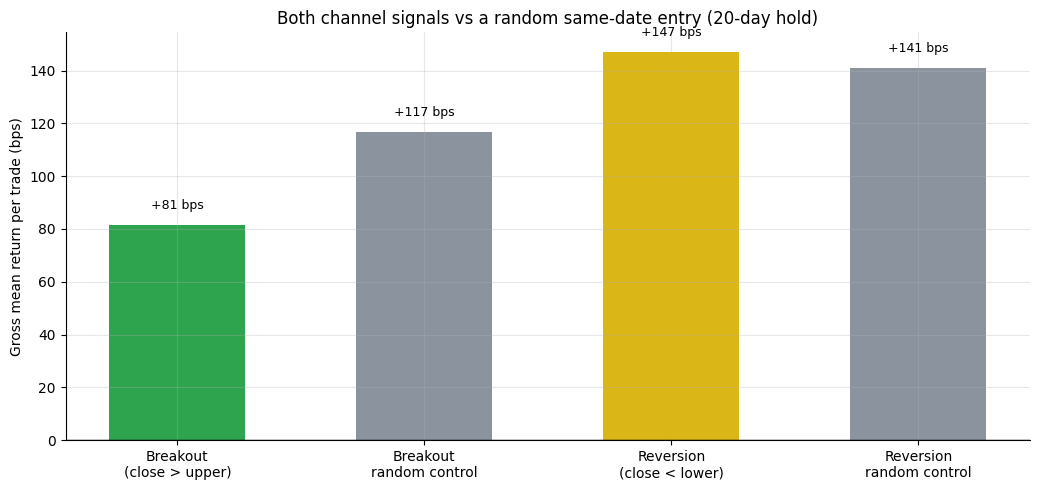

Breakout delta vs random: -35.2 bps
Reversion delta vs random: +6.3 bps


In [3]:
# The key chart: both arms vs random control
if HAVE_REAL:
    sbo = st.summarize(pool('breakout'), 'ret_gross')
    srv = st.summarize(pool('reversion'), 'ret_gross')
    srnd_bo = st.summarize(pool('breakout', seed=128), 'ret_gross')
    srnd_rv = st.summarize(pool('reversion', seed=128), 'ret_gross')
    bo_mean, rv_mean = sbo['mean_bps'], srv['mean_bps']
    rnd_bo, rnd_rv = srnd_bo['mean_bps'], srnd_rv['mean_bps']
else:
    bo_mean, rv_mean = R['bo_mean'], R['rv_mean']
    rnd_bo, rnd_rv = R['rand_bo'], R['rand_rv']
labels = ['Breakout\n(close > upper)', 'Breakout\nrandom control',
          'Reversion\n(close < lower)', 'Reversion\nrandom control']
vals = [bo_mean, rnd_bo, rv_mean, rnd_rv]
colors = [GREEN, GREY, AMBER, GREY]
fig, ax = plt.subplots(figsize=(10.5, 5.0))
bars_ = ax.bar(labels, vals, color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars_, vals):
    ax.annotate(f'{v:+.0f} bps', (b.get_x()+b.get_width()/2, max(v,0)+5),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Gross mean return per trade (bps)')
ax.set_title('Both channel signals vs a random same-date entry (20-day hold)')
plt.tight_layout(); plt.show()
print(f'Breakout delta vs random: {bo_mean-rnd_bo:+.1f} bps')
print(f'Reversion delta vs random: {rv_mean-rnd_rv:+.1f} bps')

**Breakout arm:** earns 81 bps/trade — but a random same-date entry earns 117 bps. The breakout filter is **35 bps worse** than a coin-flip. The reason: breakout days tend to follow big rallies, often near short-term highs — not great subsequent-entry points.

**Reversion arm:** earns 147 bps/trade — barely above random's 141 bps. Delta: **+6 bps** — noise. Reversion entries often fire in crisis periods when the market is already recovering, so the positive mean is mostly timing the recovery, not the channel signal.

**The contradiction in one chart:** both arms look profitable — but *only* because the market generally goes up. The random control removes that drift and shows both signals are empty.

## 5 · The verdict

- **Signal — None.** Breakout entries underperform a random-entry baseline by **35 bps** (the channel filter *hurts* vs a coin). Reversion entries beat random by **+6 bps** — economically zero. Neither arm clears the inference bar once the market's unconditional drift is stripped out.
- **Tradability — Mirage.** The positive gross means are captured equity drift, not channel alpha. There is nothing to trade.
- **Breakout vs Reversion?** Both noise. The contradiction is settled empirically: both folk rules fail to add alpha over a random-entry baseline.

## 6 · Could you actually trade it?

Unlike high-turnover strategies, the Keltner rules fire rarely (~6–23 times per year per ticker), so transaction costs are not the primary killer — the *absence of alpha* is. Even at zero cost, there is nothing here above what you'd earn by buying randomly.

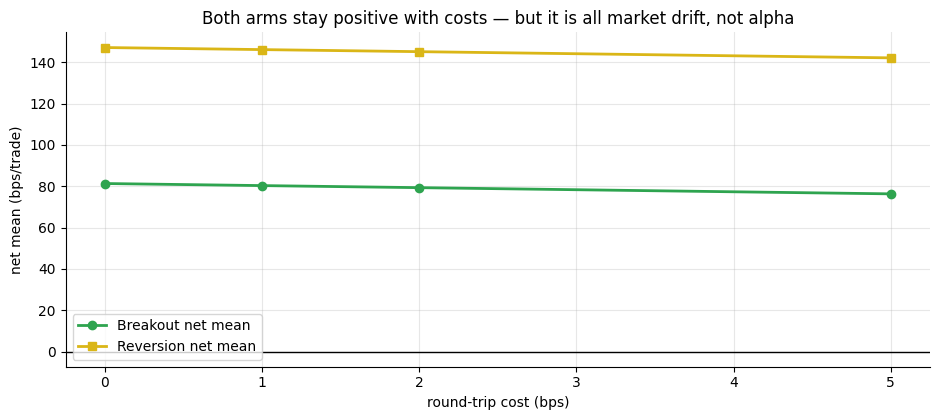

The lines stay above zero — but so would a random-entry strategy.
Breakout delta vs random: -35 bps | Reversion delta vs random: +6 bps


In [4]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net_bo = [st.summarize(pool('breakout', c), 'ret_net')['mean_bps'] for c in costs]
    net_rv = [st.summarize(pool('reversion', c), 'ret_net')['mean_bps'] for c in costs]
else:
    net_bo = [R['bo_net_0'], R['bo_net_1'], R['bo_net_2'], R['bo_net_5']]
    net_rv = [R['rv_net_0'], R['rv_net_1'], R['rv_net_2'], R['rv_net_5']]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(costs, net_bo, 'o-', c=GREEN, lw=2, label='Breakout net mean')
ax.plot(costs, net_rv, 's-', c=AMBER, lw=2, label='Reversion net mean')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Both arms stay positive with costs — but it is all market drift, not alpha')
ax.legend(); plt.tight_layout(); plt.show()
print('The lines stay above zero — but so would a random-entry strategy.')
print('Breakout delta vs random: -35 bps | Reversion delta vs random: +6 bps')

The positive net means are reassuring at first glance — but they are identical to what a random long entry would earn. The channel lines are decorative.

## 7 · Going further

- **Same contradiction with Bollinger Bands?** Yes. [Study 104 — Bollinger-Reversion](../../104-bollinger-reversion/) runs the same test on the Bollinger Band cousin of this channel — same verdict.
- **Would a stop-exit change the result?** Our positive control (beat 7 in the quants notebook) shows the machinery does find real momentum or reversion when planted in a synthetic tape. The issue is not the exit — it is the absence of signal in the real tape.
- **Is there a channel strategy that works?** Some researchers find evidence of volatility-breakout profitability at longer horizons (weekly, monthly) using ATR-based filters — but those are regime-identification tools, not simple channel-pierce entries. References in [`docs/references.md`](../docs/references.md).

*Think the channel really says something? Fork this, change the exit mode or the instrument universe, and show a random-control-adjusted edge that clears |t| ≥ 2. That's the bar.*